🚀 [Start] Repurchase Pipeline (with Session Features)...

[Step 1] Loading Data...
  -> Extracting First Order Snapshot...

[Step 2] Feature Engineering...

[Step 3] Merging...
✅ Final Data Shape: (80044, 18)
✅ Columns: ['user_age', 'user_gender', 'target_repurchase', 'first_purchase_amount', 'first_basket_count', 'entry_category', 'max_item_price', 'min_item_price', 'avg_item_price', 'user_country', 'acquisition_channel', 'first_delivery_days', 'first_order_hour', 'is_weekend_entry', 'returned_first_order', 'cancelled_first_order', 'session_event_count', 'session_max_sequence']

[Step 4] PyCaret Classification...


,Description,Value
0,Session id,42
1,Target,target_repurchase
2,Target type,Binary
3,Original data shape,"(80044, 18)"
4,Transformed data shape,"(80044, 35)"
5,Transformed train set shape,"(56030, 35)"
6,Transformed test set shape,"(24014, 35)"
7,Numeric features,10
8,Categorical features,7
9,Preprocess,True



[Step 5] Comparing Models (AUC)...


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
catboost,CatBoost Classifier,0.6169,0.5049,0.0225,0.3769,0.0424,-0.0003,-0.0006,1.9050
xgboost,Extreme Gradient Boosting,0.6035,0.5045,0.0832,0.3851,0.1367,0.0025,0.0042,0.1830
gbc,Gradient Boosting Classifier,0.6218,0.5035,0.0017,0.3135,0.0035,-0.0006,-0.0057,0.8760
dt,Decision Tree Classifier,0.5296,0.5029,0.3937,0.3809,0.3872,0.0057,0.0057,0.1720
ada,Ada Boost Classifier,0.6222,0.5025,0.0021,0.4175,0.0042,0.0003,0.0028,0.2830
lightgbm,Light Gradient Boosting Machine,0.6210,0.5020,0.0083,0.3993,0.0163,0.0009,0.0041,0.4420
lr,Logistic Regression,0.6226,0.5007,0.0000,0.0000,0.0000,0.0000,0.0000,0.4930
rf,Random Forest Classifier,0.5986,0.5007,0.0965,0.3761,0.1535,-0.0006,-0.0009,0.9950
ridge,Ridge Classifier,0.6226,0.5006,0.0000,0.0000,0.0000,0.0000,0.0000,0.1110
lda,Linear Discriminant Analysis,0.6225,0.5006,0.0000,0.0000,0.0000,-0.0000,-0.0010,0.1300



🏆 Best Model: <catboost.core.CatBoostClassifier object at 0x389db0f10>


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6127,0.5090,0.0530,0.4000,0.0936,0.0058,0.0107
1,0.6050,0.4978,0.0587,0.3573,0.1008,-0.0063,-0.0106
2,0.6095,0.4963,0.0548,0.3803,0.0959,0.0008,0.0014
3,0.6074,0.4960,0.0596,0.3739,0.1028,-0.0011,-0.0019
4,0.6136,0.5193,0.0667,0.4247,0.1152,0.0143,0.0244
5,0.6090,0.4995,0.0723,0.4005,0.1225,0.0080,0.0129
6,0.6104,0.5119,0.0548,0.3867,0.0961,0.0025,0.0045
7,0.6147,0.5189,0.0610,0.4272,0.1067,0.0137,0.0245
8,0.6093,0.5143,0.0657,0.3949,0.1127,0.0056,0.0093


Fitting 10 folds for each of 100 candidates, totalling 1000 fits

[Step 6] Analysis...


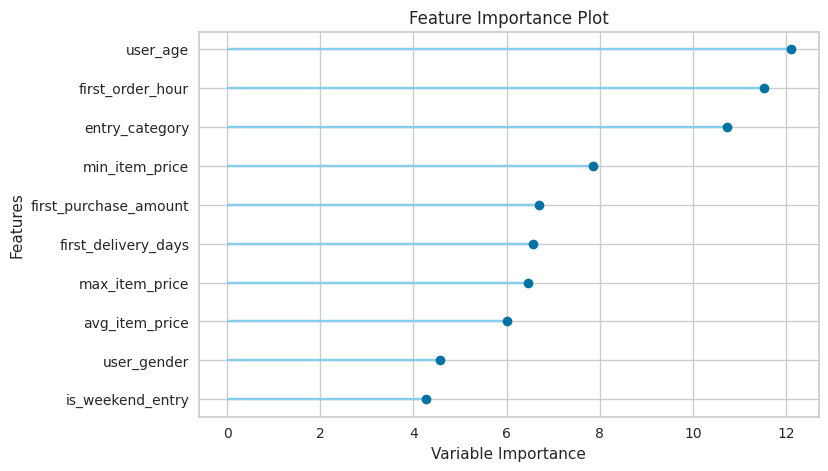


[Step 7] Finalizing...
Transformation Pipeline and Model Successfully Saved

🎉 Pipeline Completed Successfully!


In [ ]:
import polars as pl
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import pycountry
import pytz
from datetime import datetime
from pycaret.classification import *

# -------------------------------------------------------
# 0. 환경 설정
# -------------------------------------------------------
plt.rcParams['font.family'] = 'Malgun Gothic' 
plt.rcParams['axes.unicode_minus'] = False

DATA_DIR = "dataset"
PATH_PRODUCTS = os.path.join(DATA_DIR, 'joined', 'joined_all_products.csv')
PATH_USERS = os.path.join(DATA_DIR, 'joined', 'joined_all_users.csv')
PATH_COUNTS = os.path.join(DATA_DIR, 'joined', 'joined_user_order_counts.csv')

print("🚀 [Start] Repurchase Pipeline (with Session Features)...")

# -------------------------------------------------------
# 1. 데이터 로드 (Eager Mode)
# -------------------------------------------------------
print("\n[Step 1] Loading Data...")

def load_data_eager(path, name):
    try:
        if not os.path.exists(path): 
            print(f"❌ File not found: {path}")
            return None
        
        lf = pl.scan_csv(path, infer_schema_length=10000)
        schema = lf.collect_schema().names()
        
        if 'user_id' not in schema: 
            print(f"⚠️ 'user_id' missing in {name}")
            return None
        
        cols_to_cast = [pl.col('user_id').cast(pl.Int64, strict=False)]
        if 'order_id' in schema:
            cols_to_cast.append(pl.col('order_id').cast(pl.Utf8))
        if 'session_id' in schema: # session_id 캐스팅 추가
            cols_to_cast.append(pl.col('session_id').cast(pl.Utf8))
            
        return (
            lf
            .filter(pl.col('user_id').is_not_null())
            .with_columns(cols_to_cast)
            .drop_nulls(subset=['user_id'])
            .collect()
        )
    except Exception as e:
        print(f"Error loading {name}: {e}")
        return None

df_products = load_data_eager(PATH_PRODUCTS, "Products")
df_users_log = load_data_eager(PATH_USERS, "User Logs")
df_counts = load_data_eager(PATH_COUNTS, "User Counts")

if any(df is None for df in [df_products, df_users_log, df_counts]):
    raise ValueError("Critical: Data loading failed.")

# -------------------------------------------------------
# [Filter] First Order Snapshot
# -------------------------------------------------------
print("  -> Extracting First Order Snapshot...")

first_orders = (
    df_users_log
    .filter(pl.col('order_id').is_not_null())
    .with_columns(
        pl.col('created_at').str.slice(0, 19).str.to_datetime(format="%Y-%m-%d %H:%M:%S", strict=False).alias('parsed_date')
    )
    .sort(['user_id', 'parsed_date'])
    .unique(subset=['user_id'], keep='first')
)

# Key for Joins
first_order_keys = first_orders.select(['user_id', 'order_id', 'session_id'])

# -------------------------------------------------------
# 2. 피처 엔지니어링
# -------------------------------------------------------
print("\n[Step 2] Feature Engineering...")

# (1) User Profile (나이, 성별) - 강력한 추출 로직
feat_profile = (
    df_users_log
    .with_columns(pl.col('age').cast(pl.Float32, strict=False)) 
    .group_by('user_id')
    .agg([
        pl.col('age').max().alias('raw_age'),
        pl.col('gender').drop_nulls().first().alias('raw_gender')
    ])
    .with_columns([
        pl.col('raw_age').cast(pl.Int16, strict=False).fill_null(-1).alias('user_age'),
        pl.col('raw_gender').fill_null('Unknown').alias('user_gender')
    ])
    .select(['user_id', 'user_age', 'user_gender'])
)

# (2) PRODUCTS Perspective (상품 기반)
feat_products = (
    df_products
    .join(first_order_keys.select(['user_id', 'order_id']), on='order_id', how='inner')
    .with_columns(pl.col('sale_price').cast(pl.Float64, strict=False))
    .group_by('user_id')
    .agg([
        pl.col('sale_price').sum().alias('first_purchase_amount'),
        pl.count().alias('first_basket_count'),
        pl.col('category').mode().first().alias('entry_category'),
        pl.col('sale_price').max().alias('max_item_price'),
        pl.col('sale_price').min().alias('min_item_price')
    ])
    .with_columns(
        (pl.col('first_purchase_amount') / pl.col('first_basket_count')).alias('avg_item_price')
    )
)

# (3) USERS/Experience Perspective (로그/경험 + 국가 정보)
unique_countries = first_orders['country'].drop_nulls().unique().to_list()
offset_data = []
for country_name in unique_countries:
    if not country_name: continue
    offset = 0
    try:
        matches = pycountry.countries.search_fuzzy(country_name)
        if matches:
            tz_name = pytz.country_timezones.get(matches[0].alpha_2, [])[0]
            tz = pytz.timezone(tz_name)
            offset = datetime.now(tz).utcoffset().total_seconds() / 3600
    except: pass
    offset_data.append({"country": country_name, "utc_offset": offset})

df_offsets = pl.DataFrame(offset_data, schema={'country': pl.Utf8, 'utc_offset': pl.Float64}) if offset_data else pl.DataFrame(schema={'country': pl.Utf8, 'utc_offset': pl.Float64})

feat_users_exp = (
    first_orders
    .join(df_offsets, on='country', how='left')
    .with_columns([
        (pl.col('parsed_date') + pl.duration(hours=pl.col('utc_offset').fill_null(0))).alias('local_order'),
        pl.col('delivered_at').str.slice(0, 19).str.to_datetime(format="%Y-%m-%d %H:%M:%S", strict=False).alias('parsed_deliver')
    ])
    .select([
        'user_id',
        pl.col('country').alias('user_country'),
        pl.col('traffic_source').alias('acquisition_channel'),
        (pl.col('parsed_deliver') - pl.col('parsed_date')).dt.total_days().alias('first_delivery_days'),
        pl.col('local_order').dt.hour().alias('first_order_hour'),
        pl.col('local_order').dt.weekday().is_in([6, 7]).cast(pl.Int8).alias('is_weekend_entry'),
        pl.col('returned_at').is_not_null().cast(pl.Int8).alias('returned_first_order'),
        (pl.col('status') == 'Cancelled').cast(pl.Int8).alias('cancelled_first_order')
    ])
)

# (4) SESSION Perspective (세션 정보 추가) [New!]
# 첫 구매가 일어난 그 '세션' 안에서 유저가 몇 번 움직였는지(Depth) 파악
feat_sessions = (
    df_users_log
    .join(first_order_keys.select(['session_id']), on='session_id', how='inner') # 첫 구매 세션만 필터링
    .group_by('session_id') # user_id 대신 session_id로 그룹핑 (어차피 1:1 매핑됨)
    .agg([
        pl.col('user_id').first(), # ID 유지
        pl.count().alias('session_event_count'), # 세션 내 이벤트 총 개수
        pl.col('sequence_number').max().alias('session_max_sequence') # 세션 내 최대 이동 깊이
    ])
    .select(['user_id', 'session_event_count', 'session_max_sequence'])
)

# (5) Target
feat_target = (
    df_counts
    .group_by('user_id')
    .agg([
        (pl.col('repurchase_count').max() > 0).cast(pl.Int8).alias('target_repurchase')
    ])
)

# -------------------------------------------------------
# 3. 병합 및 전처리
# -------------------------------------------------------
print("\n[Step 3] Merging...")

df_final = (
    feat_profile
    .join(feat_target, on='user_id', how='inner')
    .join(feat_products, on='user_id', how='left')
    .join(feat_users_exp, on='user_id', how='left')
    .join(feat_sessions, on='user_id', how='left') # 세션 피처 병합
)

df_final = df_final.with_columns([
    # Products
    pl.col('first_purchase_amount').fill_null(0),
    pl.col('first_basket_count').fill_null(0),
    pl.col('avg_item_price').fill_null(0),
    pl.col('max_item_price').fill_null(0),
    pl.col('min_item_price').fill_null(0),
    
    # Exp
    pl.col('first_delivery_days').fill_null(-1),
    pl.col('first_order_hour').fill_null(12),
    pl.col('is_weekend_entry').fill_null(0),
    pl.col('returned_first_order').fill_null(0),
    pl.col('cancelled_first_order').fill_null(0),
    
    # Session (결측 시 최소값인 1로 대체)
    pl.col('session_event_count').fill_null(1),
    pl.col('session_max_sequence').fill_null(1),
    
    # Categorical
    pl.col('entry_category').fill_null("Unknown"),
    pl.col('user_country').fill_null("Unknown"),
    pl.col('acquisition_channel').fill_null("Unknown"),
    
    # Target
    pl.col('target_repurchase').fill_null(0)
])

# Pandas 변환
df_pandas = df_final.drop('user_id').to_pandas()

print(f"✅ Final Data Shape: {df_pandas.shape}")
print(f"✅ Columns: {df_pandas.columns.tolist()}")

# -------------------------------------------------------
# 4. AutoML Classification
# -------------------------------------------------------
print("\n[Step 4] PyCaret Classification...")

cat_features = ['user_gender', 'user_country', 'acquisition_channel', 'entry_category', 'is_weekend_entry', 'returned_first_order', 'cancelled_first_order']

try:
    exp_clf = setup(
        data=df_pandas,
        target='target_repurchase',
        session_id=42,
        normalize=True,
        transformation=True,
        fix_imbalance=False,
        categorical_features=cat_features,
        verbose=True
    )
except Exception as e:
    print(f"❌ Setup Failed: {e}")
    exit()

print("\n[Step 5] Comparing Models (AUC)...")
best_model = compare_models(sort='AUC', n_select=1)

if best_model:
    print(f"\n🏆 Best Model: {best_model}")
    
    tuned_model = tune_model(best_model, optimize='AUC', n_iter=100)
    
    print("\n[Step 6] Analysis...")
    plot_model(tuned_model, plot='feature') 
    
    print("\n[Step 7] Finalizing...")
    final_model = finalize_model(tuned_model)
    save_model(final_model, os.path.join(DATA_DIR, 'final_repurchase_clf_model'))
    print("\n🎉 Pipeline Completed Successfully!")
else:
    print("❌ Modeling Failed.")

In [2]:
df_pandas

,user_age,user_gender,target_repurchase,first_purchase_amount,first_basket_count,entry_category,max_item_price,min_item_price,avg_item_price,user_country,acquisition_channel,first_delivery_days,first_order_hour,is_weekend_entry,returned_first_order,cancelled_first_order
0,59,M,0,142.939999,2,Active,78.989998,63.950001,71.469999,China,Search,-1,20,0,0,0
1,63,M,0,128.110001,2,Sweaters,86.110001,42.000000,64.055000,China,Search,-1,14,0,0,0
2,62,F,1,19.990000,1,Socks & Hosiery,19.990000,19.990000,19.990000,Brasil,Search,-1,10,1,0,0
3,54,M,0,35.000000,1,Active,35.000000,35.000000,35.000000,United States,Search,3,0,0,0,0
4,44,M,0,49.880001,1,Suits & Sport Coats,49.880001,49.880001,49.880001,China,Email,-1,23,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80039,47,F,1,25.000000,1,Fashion Hoodies & Sweatshirts,25.000000,25.000000,25.000000,Germany,Search,0,12,0,1,0
80040,48,M,0,29.410000,1,Sweaters,29.410000,29.410000,29.410000,France,Search,3,4,1,0,0
80041,26,F,1,55.049999,1,Fashion Hoodies & Sweatshirts,55.049999,55.049999,55.049999,China,Search,-1,14,0,0,0
80042,52,F,0,268.000000,2,Jeans,148.000000,120.000000,134.000000,Japan,Search,1,0,0,1,0
